In [ ]:
pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# 載入套件



In [ ]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.unicode_minus'] = False

In [ ]:
# 讀取與清理資料
print("📥 正在從 Kaggle 下載/讀取資料集...")
path = kagglehub.dataset_download("cedricaubin/ai-ml-salaries")
csv_path = os.path.join(path, "salaries.csv")
df = pd.read_csv(csv_path)

# 資料型態轉換 將company_size,experience_level轉為數值
dic = {'S': 0, 'M': 1, 'L': 2}
df['company_size'] = df['company_size'].map(dic)
exp_dic = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
df['experience_level'] = df['experience_level'].map(exp_dic)

# 刪除用不到的欄位或移除干擾預測的欄位
df = df.drop(['employee_residence', 'company_location'], axis=1)
ml_df = df.drop(['salary', 'salary_currency'], axis=1)

📥 正在從 Kaggle 下載/讀取資料集...
Using Colab cache for faster access to the 'ai-ml-salaries' dataset.


In [ ]:
# 特徵工程

print("⚙️ 正在進行資料特徵轉換 (Label & One-Hot Encoding)...")

# One-Hot Encoding
ml_df = pd.get_dummies(ml_df, columns=['job_title', 'employment_type'])

# 定義特徵與目標(x,y)
X = ml_df.drop('salary_in_usd', axis=1)
y = ml_df['salary_in_usd']

# 切割資料集 (80%train;20%text)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

⚙️ 正在進行資料特徵轉換 (Label & One-Hot Encoding)...


In [ ]:
print("Before:", df.shape)
print("After :", ml_df.shape)

Before: (73148, 9)
After : (73148, 298)


In [ ]:
print(ml_df)

       work_year  experience_level  salary_in_usd  remote_ratio  company_size  \
0           2025                 2         170000             0             1   
1           2025                 2         110000             0             1   
2           2025                 2         170000             0             1   
3           2025                 2         110000             0             1   
4           2025                 2         143000             0             1   
...          ...               ...            ...           ...           ...   
73143       2020                 2         412000           100             2   
73144       2021                 1         151000           100             2   
73145       2020                 0         105000           100             0   
73146       2020                 0         100000           100             2   
73147       2021                 2          94665            50             2   

       job_title_AI Archite


🌲 正在訓練 [隨機森林] 迴歸模型...
✅ 隨機森林訓練完成！
📊 R2 Score (解釋力): 0.2585 (越接近1越好)
📊 RMSE (均方根誤差): $63,455.46 USD


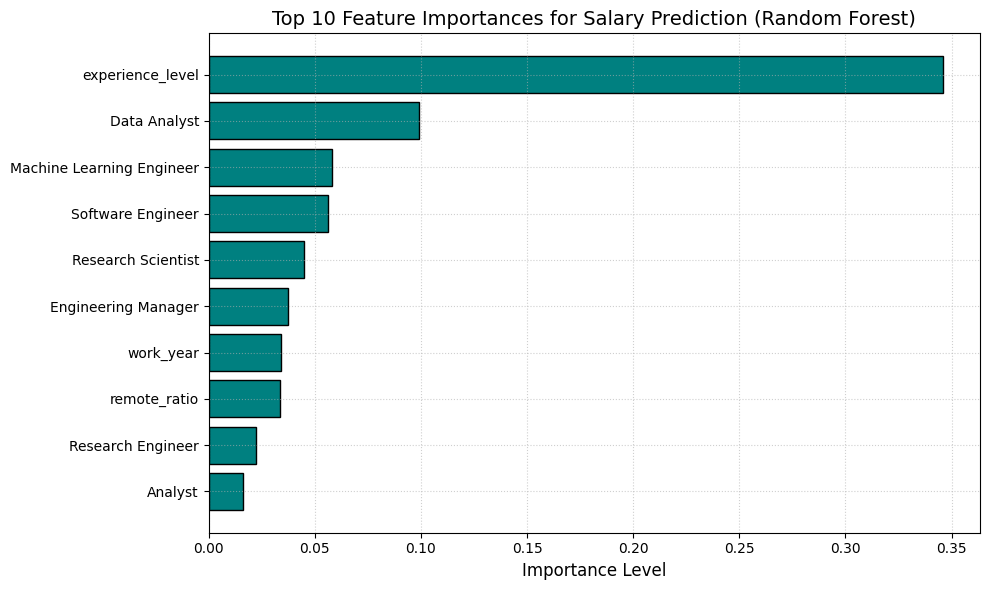

In [ ]:
# ===============================
# 3. model1: Random Forest (隨機森林)
# ===============================
print("\n🌲 正在訓練 [隨機森林] 迴歸模型...")
# 建立 100 棵決策樹
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 預測與評估
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"✅ 隨機森林訓練完成！")
print(f"📊 R2 Score (解釋力): {r2_rf:.4f} (越接近1越好)")
print(f"📊 RMSE (均方根誤差): ${rmse_rf:,.2f} USD")

# 繪製特徵重要性圖表
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
top10_features = feature_df.sort_values(by='Importance', ascending=False).head(10)
# 清理標籤名稱
cleaned_labels = [label.replace('job_title_', '').replace('employment_type_', '') for label in top10_features['Feature']]

plt.figure(figsize=(10, 6))
plt.barh(cleaned_labels, top10_features['Importance'], color='teal', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances for Salary Prediction (Random Forest)', fontsize=14)
plt.xlabel('Importance Level', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


 準備中...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 開始訓練(50 Epochs)...
Epoch 1/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 9504307200.0000 - mae: 72665.7578 - val_loss: 5107129856.0000 - val_mae: 52986.4102
Epoch 2/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 5423668736.0000 - mae: 54760.1016 - val_loss: 4942155264.0000 - val_mae: 51915.1484
Epoch 3/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 5338294784.0000 - mae: 54332.1328 - val_loss: 4900088320.0000 - val_mae: 51734.8359
Epoch 4/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 5285914112.0000 - mae: 54166.2109 - val_loss: 4876998144.0000 - val_mae: 51396.7070
Epoch 5/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5241821184.0000 - mae: 53923.1680 - val_loss: 4837943296.0000 - val_mae: 51331.3594
Epoch 6/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 5218080768.0000 - mae: 53741.9414 - val_loss: 4795066880.0000 - val_mae: 51376.5156
Epoch 7/50
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5160082432.0000 - mae: 53478.4141 - val_

/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/624558695.py:45: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missi

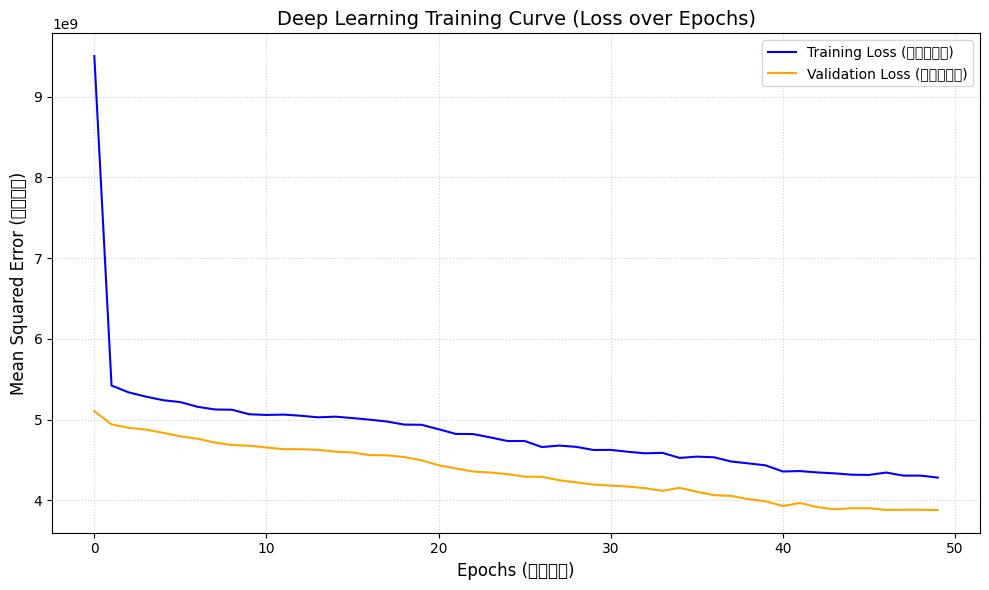

In [ ]:

# 4. model2 : DNN

print("\n 準備中...")

# 特徵縮放,將資料壓縮至相近範圍
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 建立架構
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # 丟掉20%神經元,防止過度擬合(overfitting)
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

# 編譯模型
model.compile(optimizer=Adam(learning_rate=0.005), loss='mse', metrics=['mae'])

print(" 開始訓練(50 Epochs)...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2, # 切出20%做訓練中驗證
    verbose=1 # 顯示進度條
)

# 評估模型效能
loss, mae_dl = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n 訓練完成！")
print(f" MAE (平均絕對誤差): ${mae_dl:,.2f} USD")

# 繪製訓練過程折線圖(測overfitting)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (訓練集誤差)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (驗證集誤差)', color='orange')
plt.title('Deep Learning Training Curve (Loss over Epochs)', fontsize=14)
plt.xlabel('Epochs (訓練次數)', fontsize=12)
plt.ylabel('Mean Squared Error (均方誤差)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print(X_train_scaled.shape[1])

297


In [ ]:
import pandas as pd
import numpy as np

# 假設輸入x：2025年、資深(SE)、100%遠端、中型公司(M)、全職(FT)的資料科學家
my_profile = {
    'work_year': 2025,
    'experience_level': 2,        # EN:0, MI:1, SE:2, EX:3
    'remote_ratio': 100,          # 0, 50, 或 100
    'company_size': 1,            # S:0, M:1, L:2

    # 因為 One-Hot Encoding 產生的欄位,符合條件=1
    'employment_type_FT': 1,      # 全職
    'job_title_Data Scientist': 1
}

print("👤 你輸入的條件：")
print(f"- 年份：{my_profile['work_year']}")
print(f"- 資歷等級：SE (資深)")
print(f"- 遠端比例：{my_profile['remote_ratio']}%")
print(f"- 職位：Data Scientist")
print("-" * 30)


# 2. 資料格式轉換,讓新資料長得跟X_train一樣

# 將字典轉成DataFrame
new_data = pd.DataFrame([my_profile])

# 對齊訓練集欄位
# 沒填到的職位自動補上0，確保特徵數量與順序與X完全一致
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# 3. 讓雙模型進行預測

# 隨機森林
rf_prediction = rf_model.predict(new_data)[0]

# 深度學習
new_data_scaled = scaler.transform(new_data)
# 深度學習輸出的格式是陣列中的陣列 [[預測值]]，所以用 [0][0] 把數字取出來
dl_prediction = model.predict(new_data_scaled, verbose=0)[0][0]


# 4. 顯示結果

print(" 預測結果 ")
print(f"隨機森林估算年薪約為 : ${rf_prediction:,.0f} USD")
print(f"深度學習估算年薪約為 : ${dl_prediction:,.0f} USD")

👤 你輸入的條件：
- 年份：2025
- 資歷等級：SE (資深)
- 遠端比例：100%
- 職位：Data Scientist
------------------------------
 預測結果 
隨機森林估算年薪約為 : $160,075 USD
深度學習估算年薪約為 : $165,626 USD


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" 計算模型綜合評估指標...\n")

# 1. 訓練線性回歸模型 (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 2. 隨機森林預測 (前面已經訓練過 rf_model)
y_pred_rf = rf_model.predict(X_test)

# 3. 深度學習預測 (前面已經訓練過 model，用 scaled 的資料)
# DNN 預測出來會是 2D 陣列，我們把它壓平 (flatten) 方便計算
y_pred_dl = model.predict(X_test_scaled, verbose=0).flatten()

# 建立一個函式來快速計算並印出三個指標
def print_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"🔹 {model_name}")
    print(f"   - MAE  : ${mae:,.0f}")
    print(f"   - RMSE : ${rmse:,.0f}")
    print(f"   - R²   : {r2:.4f}\n")

# 印出所有結果
print_metrics("線性回歸 (Linear Regression)", y_test, y_pred_lr)
print_metrics("隨機森林 (Random Forest)", y_test, y_pred_rf)
print_metrics("深度神經網路 (DNN)", y_test, y_pred_dl)

 計算模型綜合評估指標...

🔹 線性回歸 (Linear Regression)
   - MAE  : $47,412
   - RMSE : $64,009
   - R²   : 0.2455

🔹 隨機森林 (Random Forest)
   - MAE  : $47,015
   - RMSE : $63,455
   - R²   : 0.2585

🔹 深度神經網路 (DNN)
   - MAE  : $46,975
   - RMSE : $64,305
   - R²   : 0.2385

